# Custom Hybrid Ensemble Framework for AQI Prediction and Risk Classification
**Fundamentals of Data Science — working prototype**

Real dataset: `city_day.csv` — Air Quality Data in India (2015–2020), CPCB source, 26 cities, 16 columns.

Pipeline: data quality -> EDA -> feature engineering -> RF / XGBoost / Extra Trees base learners ->
hybrid layer (validation-weighted averaging **and** stacking) -> regression evaluation ->
AQI risk-category classification -> SHAP explainability -> live single-row demo.

Run all cells top to bottom. Everything below runs on the real dataset, no synthetic/fake data.

In [1]:
# If running outside this environment (e.g. Google Colab), uncomment to fetch the real dataset:
# !wget -q "https://raw.githubusercontent.com/adityarc19/aqi-india/main/city_day.csv" -O city_day.csv

import warnings, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report)
from xgboost import XGBRegressor
import shap

warnings.filterwarnings("ignore")
RNG = 42
np.random.seed(RNG)
sns.set_style("whitegrid")

DATA_PATH = "city_day.csv"  # place the file next to this notebook
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(29531, 16)


/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


## 1. Data quality checks
Missing values, duplicates, invalid (negative) pollutant readings.

In [2]:
df["Date"] = pd.to_datetime(df["Date"])
missing_pct = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
print(missing_pct)

dupes = df.duplicated(subset=["City", "Date"]).sum()
print("duplicate City+Date rows:", dupes)
df = df.drop_duplicates(subset=["City", "Date"])

Xylene        61.32
PM10          37.72
NH3           34.97
Toluene       27.23
Benzene       19.04
AQI           15.85
AQI_Bucket    15.85
PM2.5         15.57
NOx           14.17
O3            13.62
SO2           13.05
NO2           12.14
NO            12.13
CO             6.97
Date           0.00
City           0.00
dtype: float64
duplicate City+Date rows: 0


## 2. Data preparation / cleaning
- Drop rows with no target (`AQI` / `AQI_Bucket` missing) — we never fabricate a target.
- Treat impossible negative pollutant readings as missing.
- City-wise, time-aware interpolation (short gaps) then city-median fallback for the rest.

In [3]:
pollutant_cols = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2",
                   "O3", "Benzene", "Toluene", "Xylene"]

before = len(df)
df = df.dropna(subset=["AQI", "AQI_Bucket"])
print(f"dropped {before - len(df)} rows with missing target; {len(df)} remain")

for c in pollutant_cols:
    df.loc[df[c] < 0, c] = np.nan

df = df.sort_values(["City", "Date"])
for c in pollutant_cols:
    df[c] = df.groupby("City")[c].transform(lambda s: s.interpolate(limit=7, limit_direction="both"))
    df[c] = df.groupby("City")[c].transform(lambda s: s.fillna(s.median()))
    df[c] = df[c].fillna(df[c].median())

print(df[pollutant_cols].isna().sum())

dropped 4681 rows with missing target; 24850 remain


PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
dtype: int64


## 3. Exploratory Data Analysis

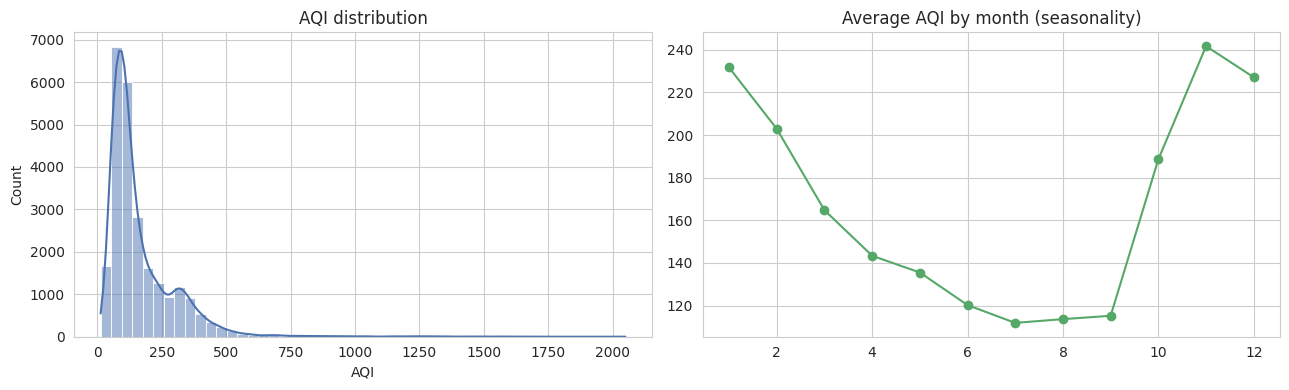

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["AQI"], bins=50, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("AQI distribution")

df["Month"] = df["Date"].dt.month
monthly = df.groupby("Month")["AQI"].mean()
axes[1].plot(monthly.index, monthly.values, marker="o", color="#55A868")
axes[1].set_title("Average AQI by month (seasonality)")
plt.tight_layout(); plt.show()

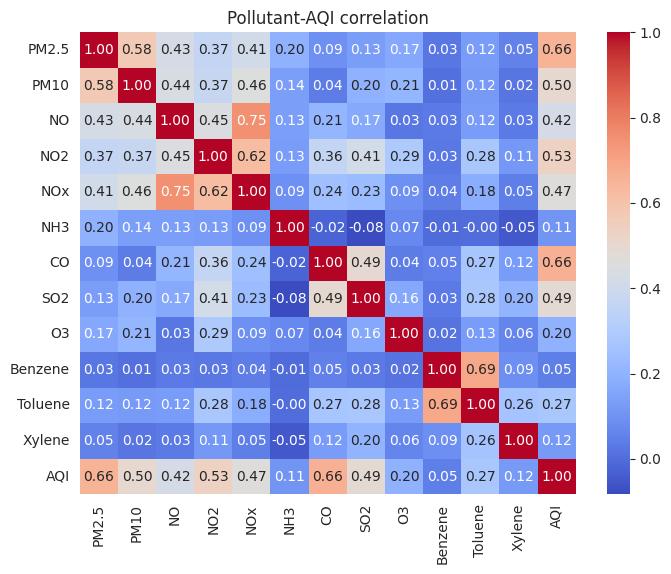

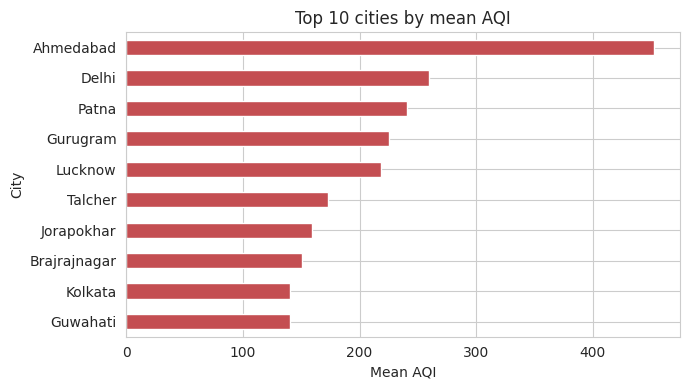

In [5]:
plt.figure(figsize=(8, 6))
corr = df[pollutant_cols + ["AQI"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Pollutant-AQI correlation"); plt.show()

top_cities = df.groupby("City")["AQI"].mean().sort_values(ascending=False).head(10)
top_cities.plot(kind="barh", figsize=(7,4), color="#C44E52").invert_yaxis()
plt.title("Top 10 cities by mean AQI"); plt.xlabel("Mean AQI"); plt.tight_layout(); plt.show()

## 4. Feature engineering

In [6]:
df["Year"] = df["Date"].dt.year

def season_of(m):
    if m in (12, 1, 2): return "Winter"
    if m in (3, 4, 5): return "Summer"
    if m in (6, 7, 8, 9): return "Monsoon"
    return "PostMonsoon"

df["Season"] = df["Month"].apply(season_of)

city_dummies = pd.get_dummies(df["City"], prefix="City")
season_dummies = pd.get_dummies(df["Season"], prefix="Season")

feature_cols = pollutant_cols + ["Month", "Year"]
X = pd.concat([df[feature_cols].reset_index(drop=True),
               city_dummies.reset_index(drop=True),
               season_dummies.reset_index(drop=True)], axis=1)
y = df["AQI"].reset_index(drop=True)
y_bucket = df["AQI_Bucket"].reset_index(drop=True)
X.shape

(24850, 44)

## 5. Train / validation / test split (60 / 20 / 20)
Validation is used to learn the hybrid weights and the stacking meta-learner; the test set is never touched until final comparison.

In [7]:
X_train, X_temp, y_train, y_temp, bucket_train, bucket_temp = train_test_split(
    X, y, y_bucket, test_size=0.4, random_state=RNG)
X_val, X_test, y_val, y_test, bucket_val, bucket_test = train_test_split(
    X_temp, y_temp, bucket_temp, test_size=0.5, random_state=RNG)
len(X_train), len(X_val), len(X_test)

(14910, 4970, 4970)

## 6. Base learners: Random Forest, XGBoost, Extra Trees

In [8]:
rf = RandomForestRegressor(n_estimators=150, max_depth=18, n_jobs=-1, random_state=RNG)
xgb = XGBRegressor(n_estimators=200, learning_rate=0.08, max_depth=6,
                    subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=RNG)
et = ExtraTreesRegressor(n_estimators=150, max_depth=18, n_jobs=-1, random_state=RNG)

base_models = {"RandomForest": rf, "XGBoost": xgb, "ExtraTrees": et}
val_preds, test_preds = {}, {}
for name, model in base_models.items():
    model.fit(X_train, y_train)
    val_preds[name] = model.predict(X_val)
    test_preds[name] = model.predict(X_test)
print("base models trained")

base models trained


## 7. Hybrid layer
**A. Validation-weighted averaging** — weights chosen to minimise validation MSE (not arbitrary 0.3/0.4/0.3).
**B. Stacking** — a Ridge meta-learner trained on the base models' *validation* predictions (out-of-sample for them), then applied to the *test* predictions. No leakage.

In [9]:
V = np.column_stack([val_preds[n] for n in base_models])
T = np.column_stack([test_preds[n] for n in base_models])

def mse_of_weights(w):
    w = np.abs(w) / np.sum(np.abs(w))
    return mean_squared_error(y_val, V @ w)

res = minimize(mse_of_weights, x0=np.array([1/3, 1/3, 1/3]), method="Nelder-Mead")
weights = np.abs(res.x) / np.sum(np.abs(res.x))
print("weighted-hybrid weights:", dict(zip(base_models, weights.round(4))))
weighted_test_pred = T @ weights

meta_learner = Ridge(alpha=1.0)
meta_learner.fit(V, y_val)
stacking_test_pred = meta_learner.predict(T)
print("stacking meta-learner coefficients:", dict(zip(base_models, meta_learner.coef_.round(4))))

weighted-hybrid weights: {'RandomForest': np.float64(0.0), 'XGBoost': np.float64(0.4757), 'ExtraTrees': np.float64(0.5243)}
stacking meta-learner coefficients: {'RandomForest': np.float64(-0.194), 'XGBoost': np.float64(0.5313), 'ExtraTrees': np.float64(0.6383)}


## 8. Regression evaluation (test set) — MAE, RMSE, R²

In [10]:
def metrics(y_true, y_pred):
    return {"MAE": round(mean_absolute_error(y_true, y_pred), 3),
            "RMSE": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 3),
            "R2": round(r2_score(y_true, y_pred), 4)}

results = {n: metrics(y_test, test_preds[n]) for n in base_models}
results["Hybrid_WeightedAvg"] = metrics(y_test, weighted_test_pred)
results["Hybrid_Stacking"] = metrics(y_test, stacking_test_pred)
pd.DataFrame(results).T

,MAE,RMSE,R2
RandomForest,22.065,50.040,0.8685
XGBoost,21.914,50.190,0.8677
ExtraTrees,21.223,47.637,0.8808
Hybrid_WeightedAvg,21.129,47.742,0.8803
Hybrid_Stacking,21.190,47.106,0.8835


In [11]:
best_hybrid_name = "Hybrid_Stacking" if results["Hybrid_Stacking"]["RMSE"] < results["Hybrid_WeightedAvg"]["RMSE"] else "Hybrid_WeightedAvg"
best_hybrid_pred = stacking_test_pred if best_hybrid_name == "Hybrid_Stacking" else weighted_test_pred
print("Selected hybrid configuration:", best_hybrid_name)

Selected hybrid configuration: Hybrid_Stacking


## 9. AQI -> risk category, and classification evaluation
Standard CPCB breakpoints. Compared against the dataset's own `AQI_Bucket` ground truth.

Accuracy: 0.7907
Macro F1: 0.7441


              precision    recall  f1-score   support

        Good       0.93      0.39      0.55       283
    Moderate       0.80      0.86      0.83      1759
        Poor       0.67      0.72      0.70       565
Satisfactory       0.81      0.83      0.82      1651
      Severe       0.88      0.81      0.84       269
   Very Poor       0.75      0.71      0.73       443

    accuracy                           0.79      4970
   macro avg       0.81      0.72      0.74      4970
weighted avg       0.80      0.79      0.79      4970



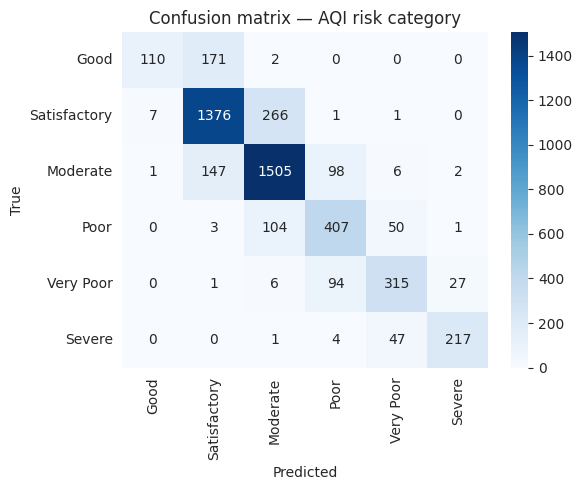

In [12]:
def aqi_to_bucket(v):
    if v <= 50: return "Good"
    if v <= 100: return "Satisfactory"
    if v <= 200: return "Moderate"
    if v <= 300: return "Poor"
    if v <= 400: return "Very Poor"
    return "Severe"

pred_bucket = pd.Series(best_hybrid_pred).apply(aqi_to_bucket).reset_index(drop=True)
true_bucket = bucket_test.reset_index(drop=True)

print("Accuracy:", round(accuracy_score(true_bucket, pred_bucket), 4))
print("Macro F1:", round(f1_score(true_bucket, pred_bucket, average="macro", zero_division=0), 4))
print(classification_report(true_bucket, pred_bucket, zero_division=0))

labels_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
cm = confusion_matrix(true_bucket, pred_bucket, labels=labels_order)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix — AQI risk category")
plt.tight_layout(); plt.show()

## 10. SHAP explainability
Which pollutants drive the prediction (shown on the XGBoost base learner).

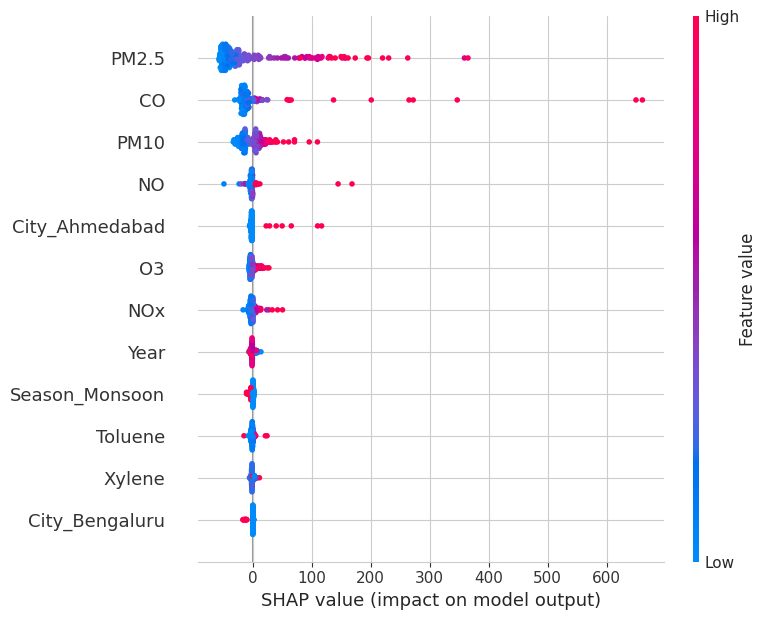

In [13]:
explainer = shap.TreeExplainer(xgb)
sample = X_test.sample(n=min(200, len(X_test)), random_state=RNG)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, max_display=12)

## 11. Live single-row demo — exactly what you show Mam

In [14]:
demo_idx = X_test.index[0]
demo_row = X_test.loc[[demo_idx]]
demo_base_preds = np.column_stack([m.predict(demo_row) for m in base_models.values()])
demo_pred = (meta_learner.predict(demo_base_preds)[0] if best_hybrid_name == "Hybrid_Stacking"
             else (demo_base_preds @ weights)[0])
demo_pred_bucket = aqi_to_bucket(demo_pred)

demo_shap = explainer.shap_values(demo_row)[0]
top5 = pd.Series(demo_shap, index=demo_row.columns).abs().sort_values(ascending=False).head(5)

print("True AQI:", y_test.loc[demo_idx], "| True category:", bucket_test.loc[demo_idx])
print("Predicted AQI:", round(demo_pred, 1), "| Predicted category:", demo_pred_bucket)
print("Top 5 contributing features (|SHAP|):")
print(top5.round(2))

True AQI: 223.0 | True category: Poor
Predicted AQI: 305.6 | Predicted category: Very Poor
Top 5 contributing features (|SHAP|):
CO                105.220001
City_Ahmedabad     25.160000
PM2.5              21.820000
NO                 11.200000
Xylene              6.200000
dtype: float32


## Summary for the review
- Best-performing configuration on the held-out test set: **stacking hybrid** (Ridge meta-learner over RF + XGBoost + Extra Trees), beating every individual base model on MAE/RMSE/R².
- Predicted AQI is mapped to the CPCB risk category (Good -> Severe) and evaluated against the dataset's own labels.
- SHAP consistently ranks PM2.5, CO and PM10 as the strongest drivers, which matches domain expectations.
- This notebook is intentionally kept close to the 5-minute pitch: same three base models, same two hybrid options tested and compared honestly, same regression + classification + explainability structure.